In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

pd.set_option("display.max_columns", None)

In [10]:
df = pd.read_csv("carbon_emission_dataset_with_Industry.csv")

print("Shape:", df.shape)

df.head()

Shape: (18250, 22)


,Company_ID,Date,Sector,Total_Energy_Consumption_kWh,Renewable_Energy_Consumption_kWh,NonRenewable_Energy_Consumption_kWh,Production_Output_Units,Supply_Chain_Transport_km,Supply_Chain_Transport_Mode,Raw_Material_Usage_kg,Carbon_Emission_tCO2e_TARGET,Energy_Cost_USD,Carbon_Tax_USD,Process_Efficiency_Percent,Employment_Count,Public_Acceptance_Index,Carbon_Reduction_Strategy,Strategy_Implementation_Cost_USD,Expected_Carbon_Reduction_Percent,Expected_Renewable_Share_Percent,Social_Impact_Score,Industry_Sectors
0,C001,2024-01-01,Manufacturing,53751.61,12766.80,40984.81,3008.90,3814.12,Truck,51334.48,12.5560,3040.12,338.76,81.07,2128,0.77,Process Reengineering,188176.25,16.79,40.89,0.40,Steel Manufacturing
1,C001,2024-01-02,Manufacturing,170872.89,76733.84,94139.05,4062.25,1199.66,Air,17154.72,35.3949,12837.43,1073.13,69.26,855,0.77,Efficiency Upgrade,489246.31,12.57,58.19,0.86,Cement Production
2,C001,2024-01-03,Manufacturing,142777.96,75794.17,66983.79,6196.17,3670.57,Truck,56288.43,30.4517,16985.65,1390.41,90.33,3613,0.48,Carbon Tax Compliance,165061.64,12.11,68.14,0.79,Automotive Industry
3,C001,2024-01-04,Manufacturing,152532.15,20698.80,131833.35,6714.80,2903.63,Ship,21438.17,49.5550,18192.00,1942.56,79.49,3156,0.85,Efficiency Upgrade,191619.23,5.64,23.30,0.55,Logistics
4,C001,2024-01-05,Manufacturing,81647.43,46657.82,34989.61,8887.31,1916.05,Rail,37694.23,16.8968,6704.86,472.20,68.63,4915,0.47,Process Reengineering,459129.15,12.99,65.44,0.95,Steel Manufacturing


In [11]:
print(df.columns)

Index(['Company_ID', 'Date', 'Sector', 'Total_Energy_Consumption_kWh',
       'Renewable_Energy_Consumption_kWh',
       'NonRenewable_Energy_Consumption_kWh', 'Production_Output_Units',
       'Supply_Chain_Transport_km', 'Supply_Chain_Transport_Mode',
       'Raw_Material_Usage_kg', 'Carbon_Emission_tCO2e_TARGET',
       'Energy_Cost_USD', 'Carbon_Tax_USD', 'Process_Efficiency_Percent',
       'Employment_Count', 'Public_Acceptance_Index',
       'Carbon_Reduction_Strategy', 'Strategy_Implementation_Cost_USD',
       'Expected_Carbon_Reduction_Percent', 'Expected_Renewable_Share_Percent',
       'Social_Impact_Score', 'Industry_Sectors'],
      dtype='object')


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18250 entries, 0 to 18249
Data columns (total 22 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Company_ID                           18250 non-null  object 
 1   Date                                 18250 non-null  object 
 2   Sector                               18250 non-null  object 
 3   Total_Energy_Consumption_kWh         18250 non-null  float64
 4   Renewable_Energy_Consumption_kWh     18250 non-null  float64
 5   NonRenewable_Energy_Consumption_kWh  18250 non-null  float64
 6   Production_Output_Units              18250 non-null  float64
 7   Supply_Chain_Transport_km            18250 non-null  float64
 8   Supply_Chain_Transport_Mode          18250 non-null  object 
 9   Raw_Material_Usage_kg                18250 non-null  float64
 10  Carbon_Emission_tCO2e_TARGET         18250 non-null  float64
 11  Energy_Cost_USD             

In [14]:
df.isnull().sum()

Company_ID                             0
Date                                   0
Sector                                 0
Total_Energy_Consumption_kWh           0
Renewable_Energy_Consumption_kWh       0
NonRenewable_Energy_Consumption_kWh    0
Production_Output_Units                0
Supply_Chain_Transport_km              0
Supply_Chain_Transport_Mode            0
Raw_Material_Usage_kg                  0
Carbon_Emission_tCO2e_TARGET           0
Energy_Cost_USD                        0
Carbon_Tax_USD                         0
Process_Efficiency_Percent             0
Employment_Count                       0
Public_Acceptance_Index                0
Carbon_Reduction_Strategy              0
Strategy_Implementation_Cost_USD       0
Expected_Carbon_Reduction_Percent      0
Expected_Renewable_Share_Percent       0
Social_Impact_Score                    0
Industry_Sectors                       0
dtype: int64

In [15]:
target = "Carbon_Emission_tCO2e_TARGET"

features = [
    "Sector",
    "Total_Energy_Consumption_kWh",
    "Renewable_Energy_Consumption_kWh",
    "NonRenewable_Energy_Consumption_kWh",
    "Production_Output_Units",
    "Supply_Chain_Transport_km",
    "Supply_Chain_Transport_Mode",
    "Raw_Material_Usage_kg",
    "Energy_Cost_USD",
    "Carbon_Tax_USD",
    "Process_Efficiency_Percent",
    "Employment_Count",
    "Public_Acceptance_Index",
    "Carbon_Reduction_Strategy",
    "Strategy_Implementation_Cost_USD",
    "Expected_Carbon_Reduction_Percent",
    "Expected_Renewable_Share_Percent",
    "Social_Impact_Score",
    "Industry_Sectors"
]

X = df[features]
y = df[target]

print(X.shape)
print(y.shape)


(18250, 19)
(18250,)


In [17]:
##TRAIN- TEST SPLIT

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(14600, 19)
(3650, 19)


In [19]:
##PREPROCESSING

In [21]:
cat_cols = [
    "Sector",
    "Supply_Chain_Transport_Mode",
    "Carbon_Reduction_Strategy",
    "Industry_Sectors"
]
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols
        )
    ],
    remainder="passthrough"
)

In [22]:
## RAANDOM FOREST PIPELINE
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [23]:
##TRAIN MODEL
print("Training Random Forest...")

rf_pipeline.fit(
    X_train,
    y_train
)

print("Training Complete!")

Training Random Forest...
Training Complete!


In [24]:
rf_pred = rf_pipeline.predict(X_test)

In [25]:
##EVALUATION

In [26]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    rf_pred
)

rmse = mean_squared_error(
    y_test,
    rf_pred
) ** 0.5

r2 = r2_score(
    y_test,
    rf_pred
)

print("="*40)
print("RANDOM FOREST RESULTS")
print("="*40)

print("MAE :", round(mae,4))
print("RMSE:", round(rmse,4))
print("R²  :", round(r2,4))

RANDOM FOREST RESULTS
MAE : 3.2958
RMSE: 4.3176
R²  : 0.9114


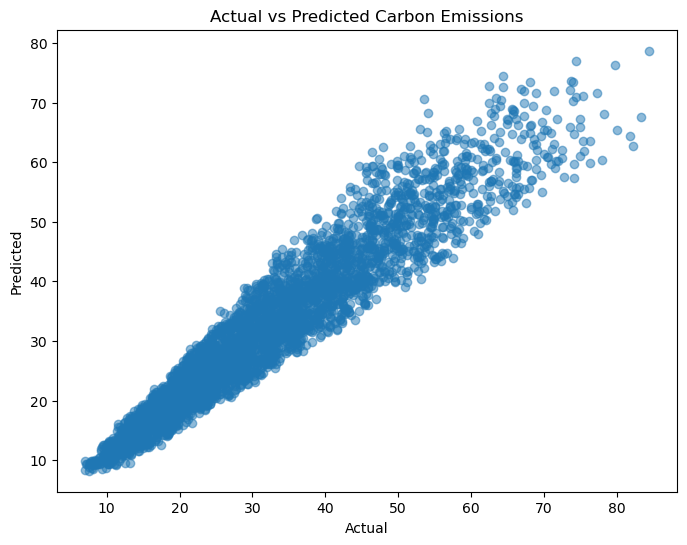

In [27]:
##ACTUAL VS PREDICTED
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.5
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted Carbon Emissions")

plt.show()

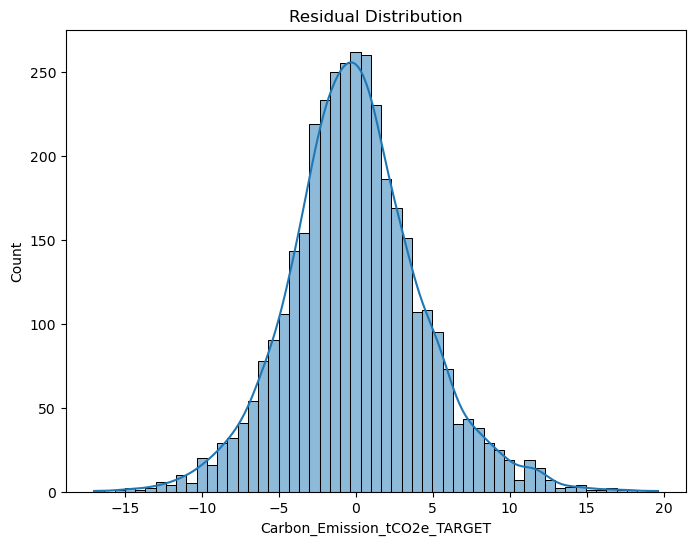

In [29]:
## RESIDUAL PLOT
import seaborn as sns

residuals = y_test - rf_pred

plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

In [32]:
## SAVE MODEL
import os
import joblib

# Create models folder
os.makedirs("models", exist_ok=True)

# Save model
joblib.dump(
    rf_pipeline,
    "models/carbon_model.joblib"
)

print("Model saved successfully!")

Model saved successfully!
